# 📊 Statistics Foundations — Variables → Correlation

### Detailed beginner-friendly notes from the supplied transcript  
**Style:** “Explain it like I’m 5” → step-by-step → practical → interview-ready → data-science ready

---

## What this notebook covers

1. **Variables**
   - What a variable means
   - Quantitative vs qualitative/categorical
   - Discrete vs continuous
   - Common traps and real dataset examples

2. **Random Variables**
   - Experiments, outcomes, and numerical mappings
   - Discrete vs continuous random variables
   - Coin, dice, rainfall, and height examples
   - PMF/PDF/CDF bridge

3. **Histograms**
   - Bins, frequencies, and counts
   - Why bin size matters
   - Histogram vs bar chart
   - Density and KDE intuition

4. **Percentage, Percentile, and Quartiles**
   - Percentage vs percentile
   - Percentile rank
   - Finding percentile values
   - Q1, Q2, Q3
   - Why Python may return slightly different quartiles

5. **Five-Number Summary, IQR, Outliers, and Box Plots**
   - Minimum, Q1, median, Q3, maximum
   - IQR
   - Lower/upper fences
   - Box-and-whisker plots
   - Practical cautions before deleting outliers

6. **Covariance and Correlation**
   - Positive, negative, and near-zero relationships
   - Sample covariance
   - Why `Cov(X, X) = Var(X)`
   - Pearson correlation
   - Spearman rank correlation
   - Pearson vs Spearman
   - Feature-selection use cases
   - Correlation ≠ causation

7. **Final Practical Mini Project**
   - Classify variables
   - Explore distributions
   - Calculate percentiles
   - Detect outliers
   - Compare Pearson/Spearman correlations
   - Make a feature-selection decision

8. **Cheat Sheet + Interview Questions + Practice**

> **Important note:** The main teaching flow and examples come from the supplied transcript.  
> Where the transcript uses a simplified classroom rule or contains a numerical shortcut/typo, this notebook keeps the *idea* but adds a clearly marked **Practical/Accuracy Note** so you learn the statistically correct version too.

## 🧠 The one big idea

Statistics is mostly about answering questions from data.

Imagine a school:

- **Variable:** “height”
- **Observed values:** 150 cm, 166 cm, 174 cm, ...
- **Histogram:** “How are these heights distributed?”
- **Percentile:** “Where does one student stand compared with everyone else?”
- **Quartiles:** “Can we split the heights into four chunks?”
- **IQR:** “Where is the middle half of the data?”
- **Covariance/correlation:** “Does height change together with weight?”

So the topics in this notebook are not separate islands. They connect to each other.

## 🗺️ Learning Map

```text
DATA
│
├── Variable
│   ├── Quantitative
│   │   ├── Discrete
│   │   └── Continuous
│   └── Qualitative / Categorical
│
├── Random Variable
│   ├── Discrete
│   └── Continuous
│
├── One-variable analysis
│   ├── Histogram
│   ├── Percentiles
│   ├── Quartiles
│   ├── Five-number summary
│   └── IQR / outliers / box plot
│
└── Two-variable analysis
    ├── Covariance
    ├── Pearson correlation
    └── Spearman rank correlation
```

# 1. Variables

## 1.1 Variable — like I’m 5

A **variable** is a characteristic that can take different values.

Examples:

- Age → 20, 21, 35, ...
- Height → 160.2 cm, 175.8 cm, ...
- Number of children → 0, 1, 2, 3, ...
- Favorite color → red, green, blue, ...

### Tiny analogy

Think of a **label on a box**.

The label says `Height`.

Different people can put different numbers in that box:

```text
Person A → Height = 170.2
Person B → Height = 182.0
Person C → Height = 164.8
```

The *characteristic* is the variable.  
The individual numbers are **observations/values** of that variable.

### ⚠️ Important statistical clarification

The transcript uses a programming-style explanation such as “a variable can hold one value.”

That is useful for intuition, but in **statistics** we usually call a characteristic like `Age` a variable even though a dataset column contains many observed ages.

Example:

| Person | Age |
|---|---:|
| A | 20 |
| B | 25 |
| C | 31 |

`Age` is the **variable**.  
`20, 25, 31` are observed values of that variable.

## 1.2 Main Types of Variables

### A. Quantitative variables

These contain **numerical quantities**.

Examples:
- age
- height
- weight
- salary
- number of rooms

Quantitative variables split into:

1. **Discrete**
2. **Continuous**

### B. Qualitative / Categorical variables

These describe **groups, labels, or categories**.

Examples:
- color
- city
- blood group
- product category
- payment method

## 1.3 Discrete Variable

A **discrete variable** usually comes from **counting**.

Examples:

- Number of children = 2
- Number of bank accounts = 5
- Number of students in class = 50
- Number of workers = 100
- Number of website clicks = 27

You normally do not say:

- 2.5 children ❌
- 45.7 students ❌
- 5.3 bank accounts ❌

### Memory trick

> **Discrete = countable separate steps.**

It often takes integer values, although the deeper definition is “a countable set of possible values.”

## 1.4 Continuous Variable

A **continuous variable** usually comes from **measuring**.

Examples:

- Height = 175.5 cm
- Weight = 72.7 kg
- Temperature = 36.82 °C
- Time = 12.493 seconds
- Rainfall = 10.75 mm

Between two values, many more values are possible.

### Memory trick

> **Continuous = measured on a continuous scale.**

For example, between `175 cm` and `176 cm`, you could have:

`175.1, 175.01, 175.001, ...`

## 1.5 Categorical Variable

A **categorical variable** tells us which group something belongs to.

Examples:

```text
Color → Red / Green / Blue
City → Chandigarh / Delhi / Mumbai
Payment method → UPI / Card / Cash
Department → Engineering / HR / Sales
```

The values are labels, not measurements.

### Two useful subtypes — extra practical knowledge

- **Nominal:** categories have no natural order  
  Example: red, blue, green

- **Ordinal:** categories have an order  
  Example: low, medium, high

## 1.6 Quick Comparison

| Type | Meaning | Example | Decimal possible? |
|---|---|---|---|
| Discrete quantitative | Count | number of students | Usually no |
| Continuous quantitative | Measurement | height | Yes |
| Categorical | Label/group | color | Not meaningful |

### Easy test

Ask:

1. **Am I counting?** → probably discrete
2. **Am I measuring?** → probably continuous
3. **Am I naming a group?** → probably categorical

In [1]:
import pandas as pd

people = pd.DataFrame({
    "name": ["A", "B", "C", "D"],
    "children": [0, 2, 1, 3],              # discrete
    "height_cm": [165.2, 172.8, 181.1, 169.4],  # continuous
    "favorite_color": ["Blue", "Red", "Blue", "Green"]  # categorical
})

people

,name,children,height_cm,favorite_color
0,A,0,165.2,Blue
1,B,2,172.8,Red
2,C,1,181.1,Blue
3,D,3,169.4,Green


### What did Python show?

- `children` is a **discrete quantitative** variable.
- `height_cm` is a **continuous quantitative** variable.
- `favorite_color` is **categorical**.

Python's data type (`int64`, `float64`, `object`, etc.) is related to storage.  
The **statistical variable type** is about what the data *means*.

In [1]:
def classify_variable(example_name):
    examples = {
        "number_of_students": "Discrete quantitative",
        "height_cm": "Continuous quantitative",
        "weight_kg": "Continuous quantitative",
        "city": "Categorical / qualitative",
        "number_of_rooms": "Discrete quantitative",
        "temperature_c": "Continuous quantitative",
    }
    return examples.get(example_name, "Think about whether it is counted, measured, or labeled.")

for name in ["number_of_students", "height_cm", "city", "temperature_c"]:
    print(f"{name:20s} -> {classify_variable(name)}")

number_of_students   -> Discrete quantitative
height_cm            -> Continuous quantitative
city                 -> Categorical / qualitative
temperature_c        -> Continuous quantitative


## 1.7 Common Mistakes

**Mistake 1:** “Every integer column is discrete.”  
Not always. A continuous measurement may be rounded to integers.

**Mistake 2:** “Every number is quantitative.”  
A number can be a label. Example: postal code `160036` is not a measurable amount.

**Mistake 3:** “Categories must be words.”  
Categories can be encoded as `0` and `1`.

**Mistake 4:** “Age is always discrete.”  
Age recorded as completed years looks discrete, but age itself is continuous in time.

### Interview one-liner

> A discrete variable takes countable values; a continuous variable can take values over an interval; a categorical variable represents groups or labels.

# 2. Random Variables

## 2.1 Random Variable — like I’m 5

A **random variable** connects a random experiment to a number.

Imagine tossing a coin:

```text
Outcome = Head → X = 0
Outcome = Tail → X = 1
```

Before the toss, you do not know the outcome.

After the toss, the random variable gives the outcome a numerical value.

### More formal idea

A random variable is a **function** that assigns numerical values to outcomes of a random process or experiment.

## 2.2 Experiment → Outcome → Random Variable

Example: roll a fair die.

```text
Experiment: Roll a die
Possible outcomes: {1, 2, 3, 4, 5, 6}
Random variable X: number shown on the die
```

So:

\[
X \in \{1,2,3,4,5,6\}
\]

The transcript emphasizes that random-variable values come from a **process or experiment**.

## 2.3 Discrete Random Variable

A **discrete random variable** has a countable set of possible values.

Examples:

- Coin toss encoded as `0/1`
- Die roll: `1,2,3,4,5,6`
- Number of customers arriving in one hour
- Number of defective items in a batch

### Example

Let:

\[
X = \text{number shown when rolling one die}
\]

Then:

\[
X \in \{1,2,3,4,5,6\}
\]

In [2]:
import numpy as np

rng = np.random.default_rng(42)

die_rolls = rng.integers(1, 7, size=20)
die_rolls

array([1, 5, 4, 3, 3, 6, 1, 5, 2, 1, 4, 6, 5, 5, 5, 5, 4, 1, 6, 3])

In [3]:
values, counts = np.unique(die_rolls, return_counts=True)

for value, count in zip(values, counts):
    print(f"Die value {value}: appeared {count} times")

Die value 1: appeared 4 times
Die value 2: appeared 1 times
Die value 3: appeared 3 times
Die value 4: appeared 3 times
Die value 5: appeared 6 times
Die value 6: appeared 3 times


## 2.4 Continuous Random Variable

A **continuous random variable** can take values over a continuous range.

Transcript examples include:

- tomorrow's rainfall
- height of people attending an event

Examples:

```text
Rainfall = 1.1 mm
Rainfall = 5.5 mm
Rainfall = 10.75 mm
```

or

```text
Height = 160.0 cm
Height = 160.1 cm
Height = 160.123 cm
```

There are potentially infinitely many possible measurements in an interval.

In [5]:
# Simulating a continuous random variable:
# example: height measurements around 170 cm

heights = rng.normal(loc=170, scale=7, size=10)
np.round(heights, 2)

array([168.71, 165.23, 178.56, 168.92, 167.  , 167.54, 173.73, 172.56,
       172.89, 173.02])

## 2.5 Random Variable vs Ordinary Dataset Variable

They are related but not identical ideas.

- **Dataset variable:** a feature/column such as `height`
- **Random variable:** a mathematical object representing the numerical result of a random process

In statistics, we often model a dataset column as observations drawn from a random variable.

## 2.6 Bridge to Probability — Extra Practical Notes

The transcript says later probability distributions can be built for random variables.

### For a discrete random variable: PMF

**PMF = Probability Mass Function**

It answers:

> What is the probability that \(X\) equals a particular value?

For a fair die:

\[
P(X=3)=\frac{1}{6}
\]

### For a continuous random variable: PDF

**PDF = Probability Density Function**

A PDF describes **density**, not direct point probability.

For a truly continuous variable:

\[
P(X = 170.000000\ldots) = 0
\]

We care about intervals:

\[
P(165 < X < 175)
\]

### CDF

**CDF = Cumulative Distribution Function**

\[
F(x) = P(X \le x)
\]

It tells us the probability of getting a value at or below \(x\).

# 3. Histograms

## 3.1 Histogram — like I’m 5

Imagine putting ages into buckets.

Ages:

```text
23, 24, 25, 30, 34, 36, 40, 50, 60, 75, 80
```

Create buckets such as:

```text
20–30
30–40
40–50
50–60
60–70
70–80
```

Then count how many values fall into each bucket.

That is the basic idea of a **histogram**.

> A histogram shows how numerical data is distributed across intervals called **bins**.

## 3.2 Important Histogram Words

### Bin
A range of values.

Example:

\[
20 \le x < 30
\]

### Frequency / Count
How many observations fall inside a bin.

### Bin width
How wide each interval is.

Example:

```text
0–10 → width 10
10–20 → width 10
20–30 → width 10
```

### Distribution
The overall shape formed by all of the bars.

In [6]:
ages = np.array([23, 24, 25, 30, 34, 36, 40, 50, 60, 75, 80])

counts, edges = np.histogram(ages, bins=[20, 30, 40, 50, 60, 70, 80, 90])

for left, right, count in zip(edges[:-1], edges[1:], counts):
    print(f"[{left:2.0f}, {right:2.0f}) -> {count} value(s)")

[20, 30) -> 3 value(s)
[30, 40) -> 3 value(s)
[40, 50) -> 1 value(s)
[50, 60) -> 1 value(s)
[60, 70) -> 1 value(s)
[70, 80) -> 1 value(s)
[80, 90) -> 1 value(s)


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ko0iwb7g because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


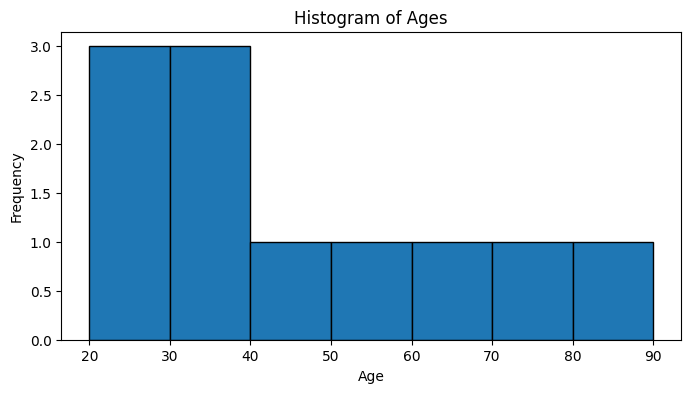

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(ages, bins=[20, 30, 40, 50, 60, 70, 80, 90], edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram of Ages")
plt.show()

## 3.3 What the Histogram Tells You

A histogram can quickly show:

- where most values are concentrated
- whether the data is spread out
- whether the distribution is symmetric
- whether it is skewed
- whether there are multiple peaks
- whether unusually distant values may exist

### Example interpretation

If the tallest bar is around ages `20–30`, many observations are in that age range.

## 3.4 Why Bin Size Matters

The same data can look different with different bins.

Too few bins:
- hides detail

Too many bins:
- can look noisy

So choosing bins changes the visual story.

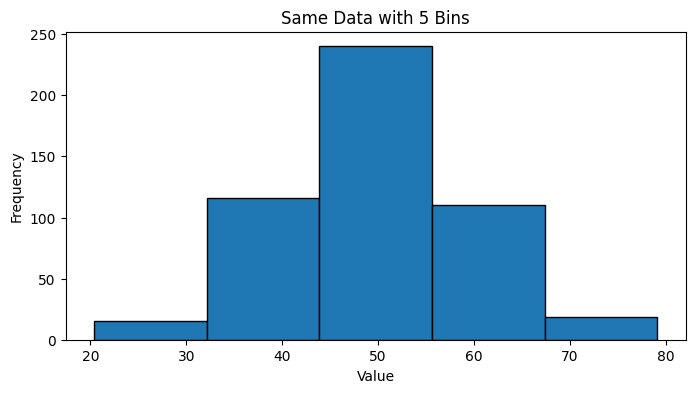

In [8]:
sample = rng.normal(50, 10, 500)

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=5, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Same Data with 5 Bins")
plt.show()

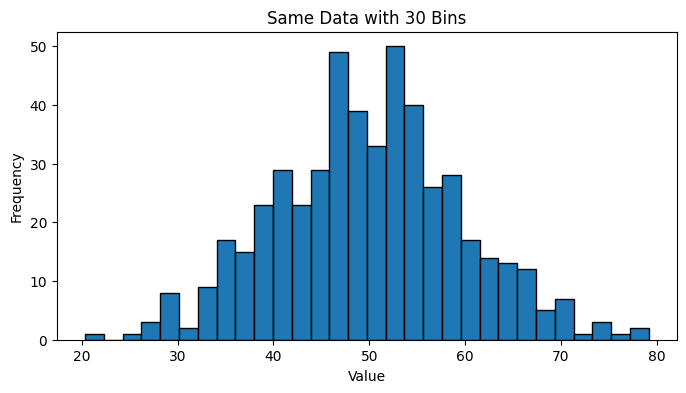

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(sample, bins=30, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Same Data with 30 Bins")
plt.show()

## 3.5 Histogram vs Bar Chart

They look similar, but are not the same.

| Histogram | Bar Chart |
|---|---|
| Numerical distribution | Categories |
| X-axis contains intervals/bins | X-axis contains category labels |
| Bars usually touch | Bars are often separated |
| Example: age distribution | Example: sales by city |

### Memory trick

> Histogram = **number ranges**  
> Bar chart = **category names**

## 3.6 Histogram → Smooth Density Curve

The transcript introduces the idea of smoothing a histogram using a **Kernel Density Estimator (KDE)**.

Think of it like this:

```text
Histogram = blocky picture
KDE       = smooth picture of the same overall shape
```

KDE estimates a continuous density curve from observed data.

### Practical note

A KDE is not literally “the histogram made smooth.”  
It is a separate density-estimation method, but the intuition of a smooth distribution shape is useful.

# 4. Percentage, Percentile, and Quartiles

## 4.1 Percentage — quick revision

For:

```text
1, 2, 3, 4, 5, 6
```

Odd numbers are:

```text
1, 3, 5
```

So:

$$
\text{Percentage of odd numbers}
=
\frac{3}{6} \times 100
=
50\%
$$

Percentage answers:

> “What fraction of this group belongs to a category?”

## 4.2 Percentile — like I’m 5

A percentile tells you **where a value stands compared with the rest of the data**.

If a score is at approximately the **90th percentile**, it means it is around or above most of the observations, depending on the precise percentile convention.

Simple intuition:

> “What percentage of the data is below this point?”

## 4.3 Percentile Rank of a Given Value

One simple classroom convention used in the transcript is:

$$
\text{Percentile Rank}
=
\frac{\text{number of values below } x}{n} \times 100
$$

Example data:

```text
2, 2, 3, 4, 5, 5, 6, 7, 8, 8, 8, 9, 9, 10
```

For $x = 9$:

- values strictly below 9 = 11
- total values = 14

$$
\frac{11}{14} \times 100 \approx 78.57
$$

So under that **strictly-below convention**, 9 has a percentile rank of about **78.57%**.

In [7]:
data = np.array([2, 2, 3, 4, 5, 5, 6, 7, 8, 8, 8, 9, 9, 10])
x = 9

percentile_rank_strict = np.sum(data < x) / len(data) * 100 
#So np.sum(data < x) counts how many values are smaller than x.
percentile_rank_inclusive = np.sum(data <= x) / len(data) * 100

print("Strictly below 9 :", round(percentile_rank_strict, 2), "%")
print("At or below 9   :", round(percentile_rank_inclusive, 2), "%")

Strictly below 9 : 78.57 %
At or below 9   : 92.86 %


### ⭐ Accuracy note: percentile rank has conventions

Some definitions count:

- values **below** \(x\)
- values **at or below** \(x\)
- or use special tie handling

That is why two tools can return slightly different percentile ranks.

Always know which convention your software or exam uses.

## 4.4 Finding the Value at a Given Percentile

Now reverse the question:

> “What value represents the 25th percentile?”

The transcript introduces a position-based classroom rule involving:

$$
\frac{p}{100}(n+1)
$$

This is useful for intuition, but **there is no single universal percentile algorithm**.

Different books and software packages use different interpolation rules.

### Best practical approach in Python

Use:

```python
np.percentile(data, 25)
```

and be aware that NumPy's `method=` option controls the exact convention.

In [11]:
for p in [25, 50, 75]:
    print(f"{p}th percentile =", np.percentile(data, p))

25th percentile = 4.25
50th percentile = 6.5
75th percentile = 8.0


## 4.5 Quartiles

Quartiles split ordered data into four broad sections.

- **Q1** = 25th percentile
- **Q2** = 50th percentile = median
- **Q3** = 75th percentile

```text
Minimum ---- Q1 ---- Q2 ---- Q3 ---- Maximum
             25%     50%     75%
```

### Meaning

- about 25% of observations are at/below Q1
- about 50% are at/below Q2
- about 75% are at/below Q3

Exact boundaries depend on the percentile convention.

In [12]:
q1, q2, q3 = np.percentile(data, [25, 50, 75])
print("Q1:", q1)
print("Q2 / Median:", q2)
print("Q3:", q3)

Q1: 4.25
Q2 / Median: 6.5
Q3: 8.0


## 4.6 Percentage vs Percentile

A common interview/exam trap:

### Percentage
“How much out of 100?”

Example:

```text
You scored 80 out of 100 → 80%
```

### Percentile
“How do you rank relative to other observations?”

Example:

```text
90th percentile → your value is around the point below which roughly 90% of observations fall
```

You can score **80% marks** and still have a **95th percentile** if most people scored lower.

# 5. Five-Number Summary, IQR, Outliers, and Box Plots

## 5.1 Five-Number Summary

The five-number summary is:

1. Minimum
2. Q1
3. Median (Q2)
4. Q3
5. Maximum

It compresses a whole dataset into five useful landmarks.

## 5.2 Example from the Transcript

The transcript uses a distribution similar to:

```text
1, 2, 2, 2, 3, 3, 4, 5, 5, 5, 6, 6, 6, 6, 7, 8, 8, 9, 27
```

`27` sits far away from most observations and is treated as a potential outlier.

But instead of declaring it an outlier only by eye, we can use the **IQR rule**.

In [12]:
numbers = np.array([1, 2, 2, 2, 3, 3, 4, 5, 5, 5, 6, 6, 6, 6, 7, 8, 8, 9, 27])

five_number = {
    "Minimum": np.min(numbers),
    "Q1": np.percentile(numbers, 25),
    "Median": np.percentile(numbers, 50),
    "Q3": np.percentile(numbers, 75),
    "Maximum": np.max(numbers),
}

print("Five-number summary:")
for label, value in five_number.items():
    print(f"{label:>8}: {value:g}")

Five-number summary:
 Minimum: 1
      Q1: 3
  Median: 5
      Q3: 6.5
 Maximum: 27


## 5.3 IQR — Interquartile Range

\[
IQR = Q_3 - Q_1
\]

The IQR measures the spread of the **middle 50%** of the data.

It is useful because extreme values have less influence on it than they do on the full range.

In [14]:
q1 = np.percentile(numbers, 25)
q3 = np.percentile(numbers, 75)
iqr = q3 - q1

print("Q1 :", q1)
print("Q3 :", q3)
print("IQR:", iqr)

Q1 : 3.0
Q3 : 6.5
IQR: 3.5


## 5.4 Outlier Fences

A common rule is:

$$
\text{Lower Fence} = Q_1 - 1.5(IQR)
$$

$$
\text{Upper Fence} = Q_3 + 1.5(IQR)
$$

Potential outliers are values:

$$
x < \text{Lower Fence}
$$

or

$$
x > \text{Upper Fence}
$$

In [18]:
q1 = np.percentile(numbers, 25)
q3 = np.percentile(numbers, 75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = numbers[(numbers < lower_fence) | (numbers > upper_fence)]

print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)
print("Potential outliers:", outliers)

Lower fence: -2.25
Upper fence: 11.75
Potential outliers: [27]


### ⚠️ Important practical rule

An IQR flag means:

> “Investigate this value.”

It does **not** automatically mean:

> “Delete this value.”

A flagged value may be:

- a data-entry error
- a sensor error
- a rare but genuine case
- an important business event
- exactly the anomaly you are trying to detect

Never remove outliers blindly.

## 5.5 Box-and-Whisker Plot

A box plot visualizes:

- Q1
- median
- Q3
- IQR
- whiskers
- potential outliers

### Simple picture

```text
        ┌──────── BOX ────────┐
----|---[ Q1 ---- MEDIAN ---- Q3 ]---|----   •
   lower                              upper   outlier
   whisker                            whisker
```

### Accuracy note

In a standard Tukey-style box plot:

- whiskers usually extend to the most extreme observations still inside the fences
- points beyond the whiskers are shown separately as potential outliers

So whiskers are not always the absolute minimum and maximum.

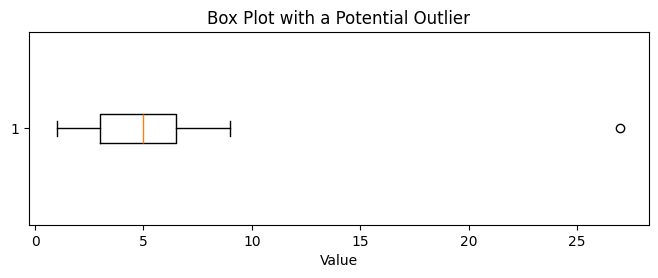

In [16]:
plt.figure(figsize=(8, 2.5))
plt.boxplot(numbers, vert=False)
plt.xlabel("Value")
plt.title("Box Plot with a Potential Outlier")
plt.show()

## 5.6 Why Five-Number Summary Matters in Data Science

It quickly answers:

- What is the typical center?
- How wide is the middle half?
- Is the distribution skewed?
- Are there suspicious extremes?
- Should I inspect data quality?

Useful during:

- EDA (Exploratory Data Analysis)
- feature engineering
- data-cleaning decisions
- anomaly detection
- reporting

# 6. Covariance and Correlation

Now we move from **one variable** to the relationship between **two variables**.

Examples:

- house size vs house price
- study hours vs exam score
- temperature vs electricity usage
- advertising spend vs sales

## 6.1 Covariance — like I’m 5

Imagine two children on bicycles.

- If both usually move forward together → **positive covariance**
- If one moves forward while the other moves backward → **negative covariance**
- If their movements do not follow a clear together/opposite pattern → covariance may be near zero

Covariance tells us how two numerical variables **change together**.

## 6.2 Positive Covariance

Example:

| House size | Price |
|---:|---:|
| 1200 sq ft | ₹45 lakh |
| 1300 sq ft | ₹50 lakh |
| 1500 sq ft | ₹75 lakh |

As size rises, price also tends to rise.

That suggests a **positive relationship**.

$$
\operatorname{Cov}(X,Y)>0
$$

## 6.3 Negative Covariance

Suppose:

| X | Y |
|---:|---:|
| 4 | 10 |
| 3 | 12 |
| 2 | 14 |
| 1 | 16 |

As $X$ decreases, $Y$ increases.

That suggests an opposite-direction relationship.

$$
\operatorname{Cov}(X,Y)<0
$$

## 6.4 Sample Covariance Formula

For a sample:

$$
s_{XY}
=
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
n-1
}
$$

Where:

- $x_i$: one observation from X
- $y_i$: matching observation from Y
- $\bar{x}$: sample mean of X
- $\bar{y}$: sample mean of Y
- $n$: number of paired observations

## 6.5 Why the Formula Works

For every pair:

1. Find how far $x_i$ is from $\bar{x}$
2. Find how far $y_i$ is from $\bar{y}$
3. Multiply the two deviations

If both deviations have the same sign:

```text
(+)(+) = positive
(-)(-) = positive
```

If they have opposite signs:

```text
(+)(-) = negative
(-)(+) = negative
```

So the sum naturally tells us whether the variables move in the same or opposite direction.

## 6.6 Study Hours vs Exam Score Example

Transcript-style data:

```text
Hours  = [2, 3, 4, 5, 6]
Scores = [50, 60, 70, 80, 90]
```

Both increase together.

Let's calculate sample covariance correctly.

In [19]:
hours = np.array([2, 3, 4, 5, 6], dtype=float)
scores = np.array([50, 60, 70, 80, 90], dtype=float)

x_bar = hours.mean()
y_bar = scores.mean()

products = (hours - x_bar) * (scores - y_bar)
sample_covariance = products.sum() / (len(hours) - 1)

print("x̄ =", x_bar)
print("ȳ =", y_bar)
print("Products of deviations:", products)
print("Sample covariance =", sample_covariance)

x̄ = 4.0
ȳ = 70.0
Products of deviations: [40. 10.  0. 10. 40.]
Sample covariance = 25.0


### ⭐ Accuracy note on the transcript calculation

The transcript verbally estimates the covariance as “around 20.”

For the data:

```text
[2,3,4,5,6]
[50,60,70,80,90]
```

the **sample covariance is actually 25**:

$$
\frac{100}{5-1}=25
$$

The important teaching idea in the transcript is still correct: the covariance is **positive** because study hours and scores rise together.

## 6.7 Powerful Identity: Cov(X, X) = Var(X)

If we calculate covariance of a variable with itself:

$$
\operatorname{Cov}(X,X)
=
\frac{\sum (x_i-\bar{x})(x_i-\bar{x})}{n-1}
$$

But:

$$
(x_i-\bar{x})(x_i-\bar{x})
=
(x_i-\bar{x})^2
$$

Therefore:

$$
\boxed{\operatorname{Cov}(X,X)=\operatorname{Var}(X)}
$$

This is a very useful interview identity.

In [20]:
variance_hours = np.var(hours, ddof=1)
cov_hours_with_itself = np.cov(hours, hours, ddof=1)[0, 1]

print("Sample variance of hours     :", variance_hours)
print("Covariance(hours, hours)     :", cov_hours_with_itself)

Sample variance of hours     : 2.5
Covariance(hours, hours)     : 2.5


## 6.8 Major Limitation of Covariance

Covariance tells us **direction**, but its magnitude is difficult to compare.

Why?

Because covariance:

- depends on measurement units
- is not restricted to a fixed range
- may be very large or very small depending on scale

It can range theoretically from:

$$
-\infty \text{ to } +\infty
$$

So `covariance = 300` does not automatically mean a “stronger” relationship than another covariance calculated on variables with different scales.

# 6.9 Correlation

Correlation solves much of covariance's scale problem by **standardizing** the relationship.

The transcript focuses on:

1. **Pearson correlation coefficient**
2. **Spearman rank correlation**

## 6.10 Pearson Correlation Coefficient

Pearson correlation is:

$$
r
=
\frac{
\operatorname{Cov}(X,Y)
}{
s_X s_Y
}
$$

Where:

- $s_X$ = standard deviation of X
- $s_Y$ = standard deviation of Y

Its value lies between:

$$
-1 \le r \le 1
$$

### Interpretation

- $r \approx +1$ → strong positive linear relationship
- $r \approx 0$ → weak/no **linear** relationship
- $r \approx -1$ → strong negative linear relationship

In [21]:
pearson_r = np.corrcoef(hours, scores)[0, 1]
print("Pearson correlation:", pearson_r)

Pearson correlation: 1.0


Because the study-hours example follows a perfect straight increasing line:

$$
r = 1
$$

That is perfect positive **linear** correlation.

In [20]:
x = np.arange(1, 9)
y_positive = 3 * x + 2
y_negative = 30 - 2 * x

print("Positive linear correlation:", np.corrcoef(x, y_positive)[0, 1])
print("Negative linear correlation:", np.corrcoef(x, y_negative)[0, 1])

Positive linear correlation: 1.0
Negative linear correlation: -1.0


## 6.11 Scatter Plots Make Correlation Intuitive

Always visualize the relationship.

A single correlation number can hide important shapes.

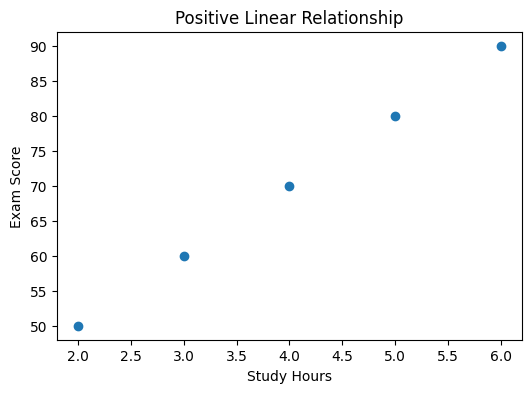

In [21]:
plt.figure(figsize=(6, 4))
plt.scatter(hours, scores)
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Positive Linear Relationship")
plt.show()

## 6.12 Spearman Rank Correlation — like I’m 5

Pearson looks at the **actual numerical spacing** and is designed to capture linear association.

Spearman first turns values into **ranks**.

Example:

```text
Value:  10, 20, 50, 100
Rank:    1,  2,  3,   4
```

Then it checks whether the ranks move together.

So Spearman is especially useful for a **monotonic relationship**:

> As X increases, Y consistently tends to increase  
> or  
> as X increases, Y consistently tends to decrease

The relationship does not need to be a straight line.

## 6.13 Pearson vs Spearman on Nonlinear Monotonic Data

Consider:

$$
Y = X^3
$$

For increasing $X$, $Y$ always increases, but the relationship is curved.

Spearman can recognize the perfectly preserved ordering.

In [23]:
x_curve = np.arange(1, 11, dtype=float)
y_curve = x_curve ** 3

pearson_curve = np.corrcoef(x_curve, y_curve)[0, 1]

rank_x = pd.Series(x_curve).rank()
rank_y = pd.Series(y_curve).rank()
spearman_curve = np.corrcoef(rank_x, rank_y)[0, 1]

print("Pearson  :", round(pearson_curve, 4))
print("Spearman :", round(spearman_curve, 4))

NameError: name 'pd' is not defined

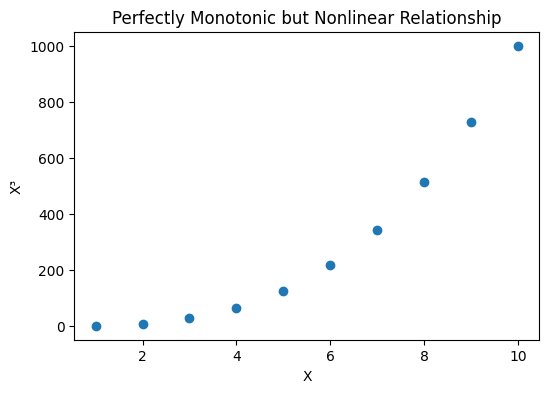

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(x_curve, y_curve)
plt.xlabel("X")
plt.ylabel("X³")
plt.title("Perfectly Monotonic but Nonlinear Relationship")
plt.show()

## 6.14 Spearman Formula Idea

One general form is simply Pearson correlation applied to ranks:

$$
\rho_s
=
\operatorname{Corr}(\operatorname{rank}(X),\operatorname{rank}(Y))
$$

When there are **no tied ranks**, another common formula is:

$$
\rho_s
=
1-
\frac{6\sum d_i^2}{n(n^2-1)}
$$

where $d_i$ is the difference between paired ranks.

### Practical note

With ties, software applies appropriate rank/tie handling.  
In real work, use a statistics library rather than hand-calculating complex tied cases.

## 6.15 Pearson vs Spearman — Decision Table

| Situation | Pearson | Spearman |
|---|---|---|
| Straight-line relationship | ✅ Great | ✅ Works |
| Monotonic but curved | May understate strength | ✅ Often better |
| Ordinal/ranked data | Usually not ideal | ✅ Good |
| Sensitive to extreme values | More | Often less |
| Measures | Linear association | Monotonic association |

### Memory trick

> **Pearson cares about the line.**  
> **Spearman cares about the order/rank.**

## 6.16 Zero Correlation Does NOT Always Mean “No Relationship”

Suppose:

$$
Y = X^2
$$

with X symmetric around zero.

There is a clear relationship, but Pearson correlation can be around zero because the relationship is not linear and not monotonic over the whole range.

In [24]:
x_u = np.linspace(-5, 5, 101)
y_u = x_u ** 2

r_u = np.corrcoef(x_u, y_u)[0, 1]
print("Pearson correlation for Y = X²:", round(r_u, 6))

Pearson correlation for Y = X²: 0.0


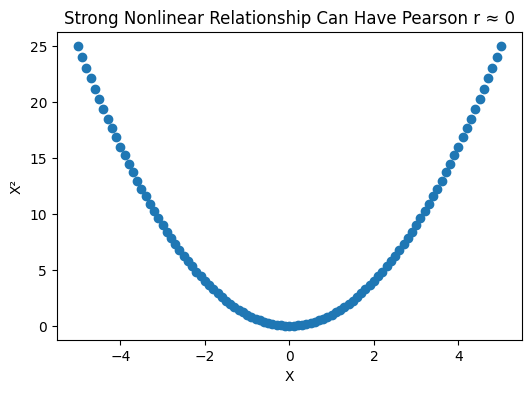

In [25]:
plt.figure(figsize=(6, 4))
plt.scatter(x_u, y_u)
plt.xlabel("X")
plt.ylabel("X²")
plt.title("Strong Nonlinear Relationship Can Have Pearson r ≈ 0")
plt.show()

## 6.17 Correlation Does Not Mean Causation

Very important:

$$
\boxed{\text{Correlation} \neq \text{Causation}}
$$

If two variables move together, that does **not** prove that one causes the other.

Possible explanations:

- X causes Y
- Y causes X
- a third variable affects both
- coincidence
- selection/data-collection effects

Example:

Ice cream sales and sunburns may rise together because **hot weather** affects both.

## 6.18 Correlation for Feature Selection — Transcript Use Case

The transcript discusses using correlation during EDA/feature selection.

House-price example:

- house size → likely related to price
- number of rooms → may be related to price
- some location representation → may be related to price
- a feature with little useful relationship → may be a candidate for further inspection

This is a useful starting idea.

### ⚠️ Advanced practical caution

Do **not** automatically delete a feature just because Pearson correlation is near zero.

Why?

A feature may still matter through:

- nonlinear relationships
- interactions with other features
- category effects
- thresholds
- tree-based model splits
- temporal effects

Correlation is a **screening tool**, not a complete feature-selection algorithm.

# 7. Final Practical Mini Project — House Price EDA

Now we combine almost everything.

## Goal

Pretend you are a junior data scientist.

You receive housing data and need to:

1. Identify variable types
2. Explore a numerical distribution
3. Calculate quartiles
4. Detect potential outliers
5. Visualize with a box plot
6. Measure relationships with covariance/correlation
7. Compare Pearson and Spearman
8. Decide which features deserve further investigation

This is the “basic → practical” bridge.

In [26]:
rng = np.random.default_rng(7)
n = 120

size_sqft = rng.normal(1500, 350, n).clip(650, 2600)
rooms = np.rint(size_sqft / 450 + rng.normal(0, 0.6, n)).clip(1, 7).astype(int)
house_age = rng.integers(0, 40, n)
location_score = rng.uniform(1, 10, n)
people_staying = rng.integers(1, 9, n)

# Price depends mostly on size, rooms, location, and age + noise.
price_lakh = (
    0.035 * size_sqft
    + 3.0 * rooms
    + 5.5 * location_score
    - 0.35 * house_age
    + rng.normal(0, 8, n)
)

housing = pd.DataFrame({
    "size_sqft": size_sqft.round(1),
    "rooms": rooms,
    "house_age": house_age,
    "location_score": location_score.round(2),
    "people_staying": people_staying,
    "price_lakh": price_lakh.round(2),
})

# Add one deliberately extreme price to demonstrate outlier analysis.
housing.loc[0, "price_lakh"] = 250.0

housing.head()

,size_sqft,rooms,house_age,location_score,people_staying,price_lakh
0,1500.4,3,39,7.82,6,250.00
1,1604.6,3,26,7.49,6,87.57
2,1404.1,3,23,5.00,7,62.93
3,1188.3,1,4,4.40,1,82.30
4,1340.9,2,23,4.78,6,68.60


## 7.1 Step 1 — Classify the Variables

- `size_sqft` → continuous quantitative
- `rooms` → discrete quantitative
- `house_age` → quantitative; recorded here in whole years
- `location_score` → quantitative score
- `people_staying` → discrete quantitative
- `price_lakh` → continuous quantitative

In a real dataset, you would also inspect units, business meaning, and how each feature was collected.

In [27]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
size_sqft,120.0,1449.005000,302.281962,650.00,1272.500,1463.400,1623.7750,2285.70
rooms,120.0,3.166667,0.919749,1.00,3.000,3.000,4.0000,5.00
house_age,120.0,20.150000,11.186464,0.00,9.750,21.500,30.0000,39.00
location_score,120.0,5.612417,2.673889,1.29,3.070,5.595,7.8675,9.96
people_staying,120.0,4.650000,2.232871,1.00,3.000,5.000,7.0000,8.00
price_lakh,120.0,83.764167,26.408890,22.90,68.735,86.705,97.1650,250.00


## 7.2 Step 2 — Look at the Price Distribution

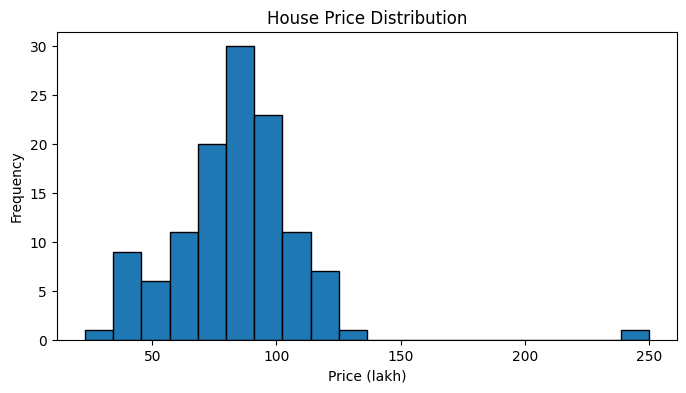

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(housing["price_lakh"], bins=20, edgecolor="black")
plt.xlabel("Price (lakh)")
plt.ylabel("Frequency")
plt.title("House Price Distribution")
plt.show()

Notice how one extreme value can stretch the x-axis.

That does not prove the value is wrong.  
It tells us to investigate.

## 7.3 Step 3 — Calculate Quartiles and Five-Number Summary

In [29]:
price = housing["price_lakh"]

summary = {
    "minimum": price.min(),
    "Q1": price.quantile(0.25),
    "median": price.median(),
    "Q3": price.quantile(0.75),
    "maximum": price.max(),
}

summary

{'minimum': np.float64(22.9),
 'Q1': np.float64(68.735),
 'median': np.float64(86.705),
 'Q3': np.float64(97.165),
 'maximum': np.float64(250.0)}

## 7.4 Step 4 — Use IQR Fences

In [30]:
q1 = price.quantile(0.25)
q3 = price.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

price_outliers = housing[(price < lower) | (price > upper)]

print("Lower fence:", round(lower, 2))
print("Upper fence:", round(upper, 2))
print("Potential outliers found:", len(price_outliers))
price_outliers

Lower fence: 26.09
Upper fence: 139.81
Potential outliers found: 2


,size_sqft,rooms,house_age,location_score,people_staying,price_lakh
0,1500.4,3,39,7.82,6,250.0
26,650.0,2,23,2.59,8,22.9


## 7.5 Step 5 — Visualize Potential Outliers

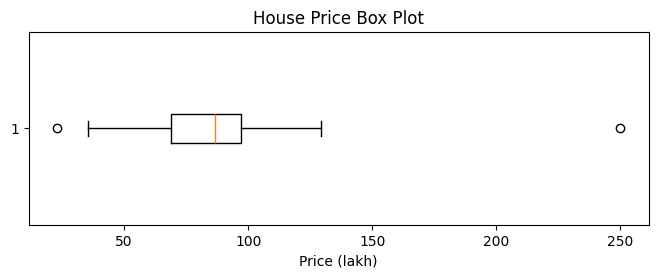

In [31]:
plt.figure(figsize=(8, 2.5))
plt.boxplot(housing["price_lakh"], vert=False)
plt.xlabel("Price (lakh)")
plt.title("House Price Box Plot")
plt.show()

## 7.6 Step 6 — Covariance with Price

Remember: covariance gives direction, but its magnitude depends on scale.

In [32]:
cov_with_price = housing.cov(numeric_only=True)["price_lakh"].sort_values(ascending=False)
cov_with_price

size_sqft         4587.230534
price_lakh         697.429456
location_score      40.047270
rooms               10.166947
house_age           -4.554160
people_staying      -6.196345
Name: price_lakh, dtype: float64

## 7.7 Step 7 — Pearson Correlation

In [33]:
pearson = housing.corr(numeric_only=True, method="pearson")["price_lakh"].sort_values(ascending=False)
pearson

price_lakh        1.000000
size_sqft         0.574630
location_score    0.567126
rooms             0.418573
house_age        -0.015416
people_staying   -0.105080
Name: price_lakh, dtype: float64

## 7.8 Step 8 — Spearman Correlation

In [34]:
spearman = housing.corr(numeric_only=True, method="spearman")["price_lakh"].sort_values(ascending=False)
spearman

price_lakh        1.000000
location_score    0.659582
size_sqft         0.605049
rooms             0.464391
house_age        -0.096679
people_staying   -0.147109
Name: price_lakh, dtype: float64

## 7.9 Step 9 — Compare Pearson and Spearman

A useful practical table:

In [35]:
comparison = pd.DataFrame({
    "Pearson": pearson,
    "Spearman": spearman
}).sort_values("Pearson", ascending=False)

comparison

,Pearson,Spearman
price_lakh,1.000000,1.000000
size_sqft,0.574630,0.605049
location_score,0.567126,0.659582
rooms,0.418573,0.464391
house_age,-0.015416,-0.096679
people_staying,-0.105080,-0.147109


## 7.10 Step 10 — Visualize Size vs Price

Before trusting one correlation number, look at the scatter plot.

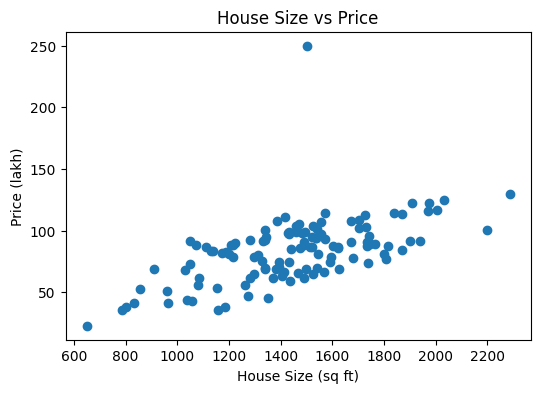

In [36]:
plt.figure(figsize=(6, 4))
plt.scatter(housing["size_sqft"], housing["price_lakh"])
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price (lakh)")
plt.title("House Size vs Price")
plt.show()

## 7.11 How a Data Scientist Would Interpret This

A sensible workflow is:

```text
1. Understand what each feature means.
2. Check missing values and data quality.
3. Inspect distributions.
4. Inspect unusual observations.
5. Visualize feature-target relationships.
6. Calculate Pearson/Spearman where appropriate.
7. Check nonlinear patterns.
8. Test features in validation/modeling.
9. Remove a feature only with evidence.
```

### The key lesson

Statistics helps you **ask better questions of data**.  
It should not become a set of automatic delete/keep rules.

# 8. Formula Cheat Sheet

## Variable types

```text
Quantitative
├── Discrete
└── Continuous

Qualitative
└── Categorical
```

## Percentile rank — simple strictly-below convention

$$
\frac{\#(x_i<x)}{n}\times100
$$

## Quartiles

$$
Q_1=P_{25},\qquad
Q_2=P_{50},\qquad
Q_3=P_{75}
$$

## IQR

$$
IQR=Q_3-Q_1
$$

## Outlier fences

$$
LF=Q_1-1.5IQR
$$

$$
UF=Q_3+1.5IQR
$$

## Sample covariance

$$
s_{XY}
=
\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{n-1}
$$

## Identity

$$
\operatorname{Cov}(X,X)=\operatorname{Var}(X)
$$

## Pearson correlation

$$
r=
\frac{\operatorname{Cov}(X,Y)}{s_Xs_Y}
$$

$$
-1\le r\le1
$$

## Spearman

$$
\rho_s=
\operatorname{Corr}(\operatorname{rank}(X),\operatorname{rank}(Y))
$$

# 9. Super-Short Revision Table

| Topic | “Like I’m 5” meaning |
|---|---|
| Variable | A characteristic that can change |
| Discrete | Count it |
| Continuous | Measure it |
| Categorical | Name a group |
| Random variable | Number produced/mapped from a random experiment |
| Histogram | Put numbers into buckets and count them |
| Percentile | Where a value stands in the ordered data |
| Q1 | 25th percentile |
| Q2 | Median / 50th percentile |
| Q3 | 75th percentile |
| IQR | Width of the middle 50% |
| Box plot | Picture of quartiles, spread, and possible outliers |
| Covariance | Do two variables move together or oppositely? |
| Pearson | Strength/direction of linear association |
| Spearman | Strength/direction of monotonic rank association |

# 10. Interview Questions

### Q1. What are the main variable types?
Quantitative and qualitative/categorical. Quantitative variables can be discrete or continuous.

### Q2. Discrete vs continuous?
Discrete values are countable; continuous values are measurements over a range.

### Q3. What is a random variable?
A function that assigns a numerical value to the outcome of a random experiment.

### Q4. What does a histogram show?
The frequency/distribution of numerical observations across bins.

### Q5. Percentage vs percentile?
Percentage is a fraction out of 100; percentile describes relative position in a distribution.

### Q6. What are Q1, Q2, Q3?
25th, 50th, and 75th percentiles.

### Q7. What is IQR?
$Q_3-Q_1$, the spread of the middle 50% of the data.

### Q8. How do you detect potential outliers with IQR?
Values below $Q_1-1.5IQR$ or above $Q_3+1.5IQR$.

### Q9. What does positive covariance mean?
The two variables tend to move in the same direction.

### Q10. Why is covariance hard to compare?
It is unbounded and depends on the units/scales of the variables.

### Q11. What range does Pearson correlation use?
$[-1,1]$.

### Q12. Pearson vs Spearman?
Pearson measures linear association using values; Spearman measures monotonic association using ranks.

### Q13. What is Cov(X, X)?
Variance of X.

### Q14. Does correlation prove causation?
No.

### Q15. Should a near-zero Pearson correlation automatically remove a feature?
No. The feature may have a nonlinear or interaction effect.

# 11. Practice Questions — Try Before Looking at Solutions

1. Classify `number of app installs` as discrete, continuous, or categorical.
2. Classify `download time in seconds`.
3. Classify `subscription plan = Free / Plus / Pro`.
4. Give one example of a discrete random variable.
5. What does a histogram bin mean?
6. What is Q2?
7. If $Q_1=10$ and $Q_3=22$, calculate IQR.
8. Using the values above, calculate the lower and upper IQR fences.
9. If X increases while Y usually decreases, what sign should covariance have?
10. What is the range of Pearson correlation?
11. Which is generally better for a strong monotonic but curved relationship: Pearson or Spearman?
12. Why can a Pearson correlation near zero still hide a relationship?

# 12. Practice Solutions

1. **Discrete quantitative** — it is a count.
2. **Continuous quantitative** — time can be measured with decimals.
3. **Categorical** — the values are plan labels.
4. Example: number shown on a die.
5. A bin is an interval/range used to group numerical observations.
6. **Q2 = median = 50th percentile.**
7. $IQR=22-10=12$.
8. $LF=10-1.5(12)=-8$ and $UF=22+1.5(12)=40$.
9. **Negative covariance.**
10. $[-1,1]$.
11. **Spearman**, because it focuses on monotonic rank ordering.
12. Pearson measures **linear** association; a strong nonlinear pattern can produce Pearson $r\approx0$.

# 13. Final Mental Model

When you receive a new dataset, think in this order:

```text
What are my variables?
        ↓
Are they discrete, continuous, or categorical?
        ↓
What does each numerical variable look like?
        ↓
Histogram + quartiles + five-number summary
        ↓
Are there potential outliers?
        ↓
IQR + box plot + investigation
        ↓
How do two variables move together?
        ↓
Scatter plot + covariance
        ↓
Linear relationship?
        ↓
Pearson
        ↓
Monotonic/rank relationship?
        ↓
Spearman
        ↓
Use all of this evidence during EDA and feature selection
```

## The sentence to remember

> **Statistics is not about memorizing formulas. It is about turning data into understandable evidence for a decision.**

## ✅ End of Notebook

You now have a beginner-to-advanced foundation for the exact topic sequence covered in the supplied transcript:

**Variables → Random Variables → Histograms → Percentiles → Quartiles → Five-Number Summary → IQR/Outliers → Covariance → Pearson → Spearman → Practical Feature Selection**

Recommended next topics:

- probability rules
- PMF / PDF / CDF in depth
- normal distribution
- z-score
- sampling distributions
- confidence intervals
- hypothesis testing
- chi-square tests
- ANOVA

# 14. Handwritten Statistics Notes

These five handwritten pages are embedded directly in this notebook, so they remain visible even when the original image files are not beside it.

## Handwritten page 1

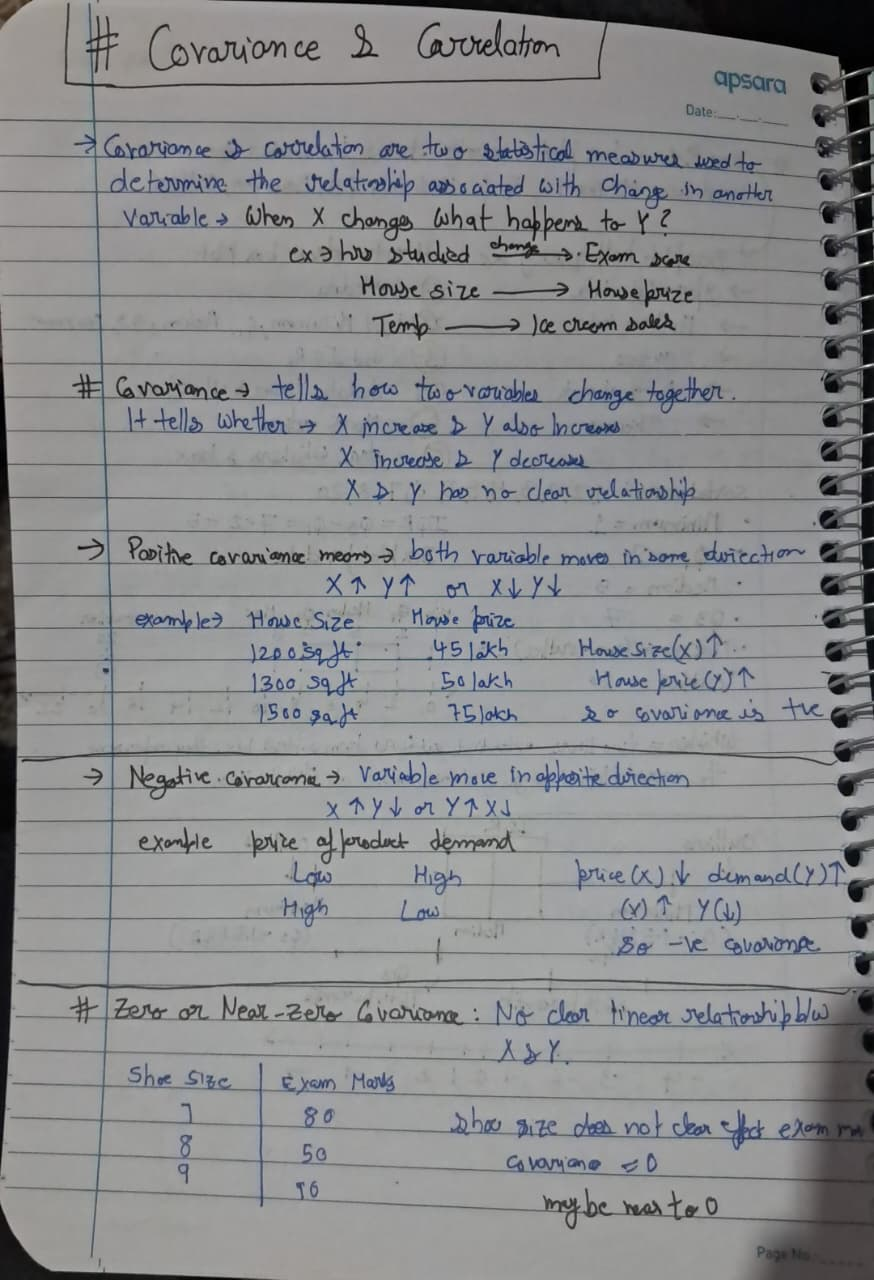

## Handwritten page 2

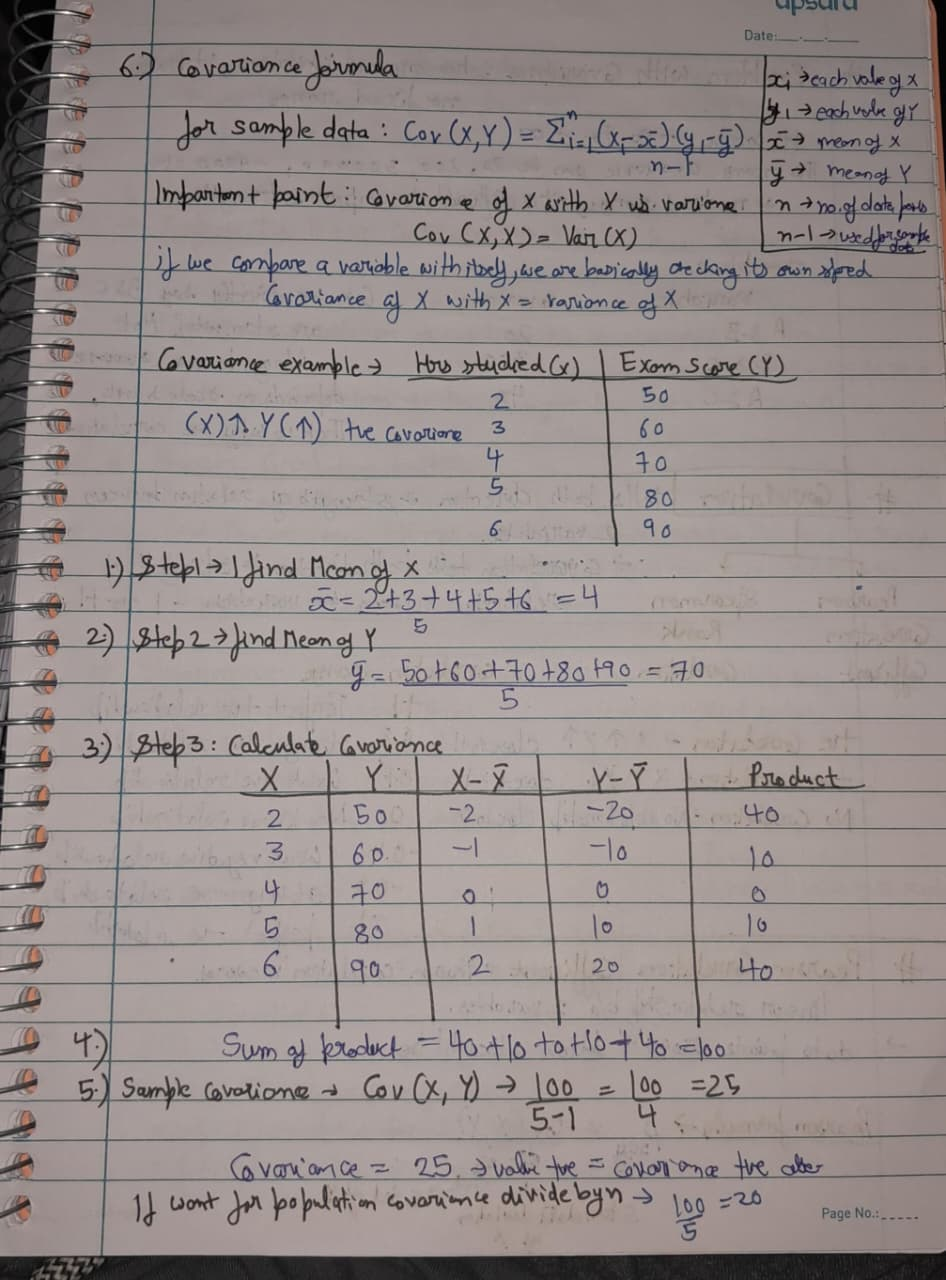

## Handwritten page 3

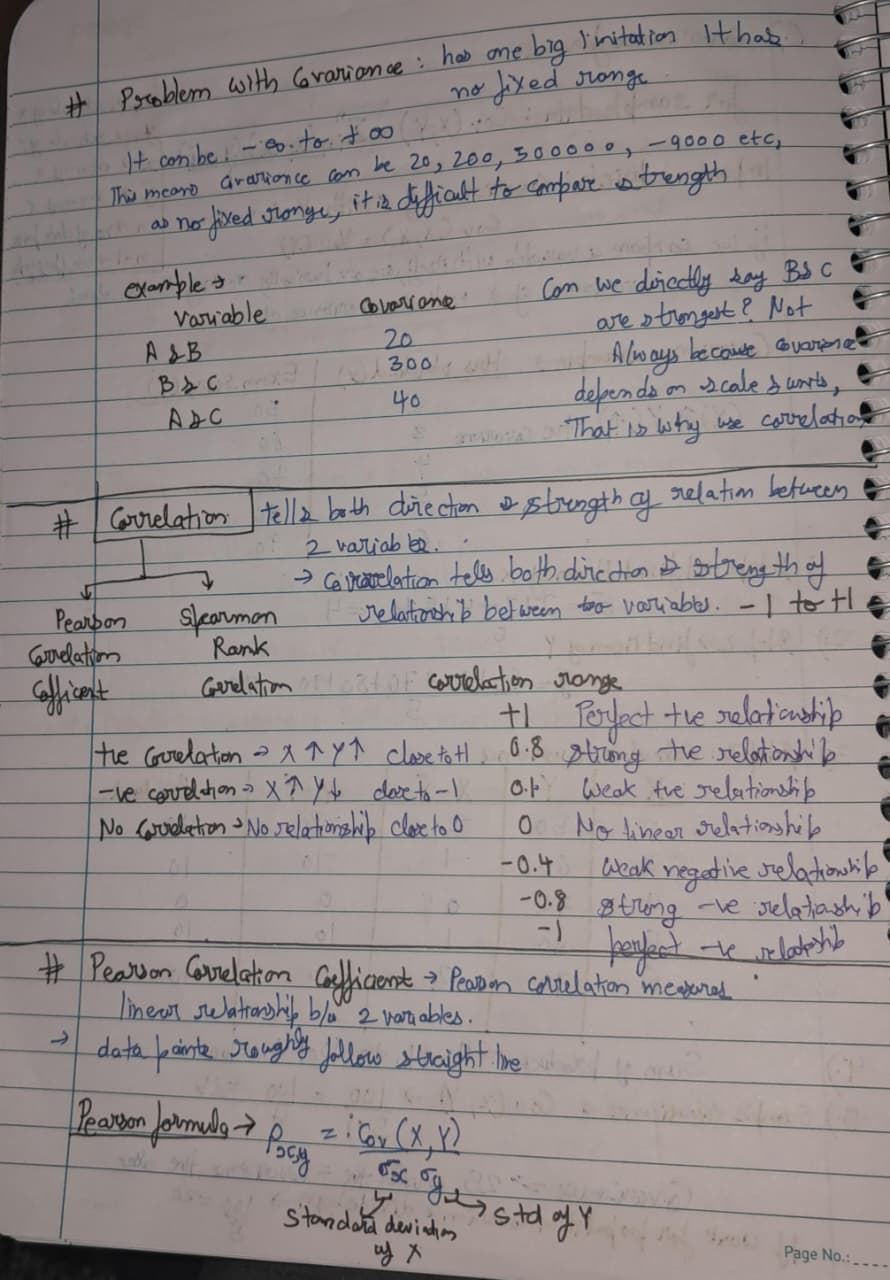

## Handwritten page 4

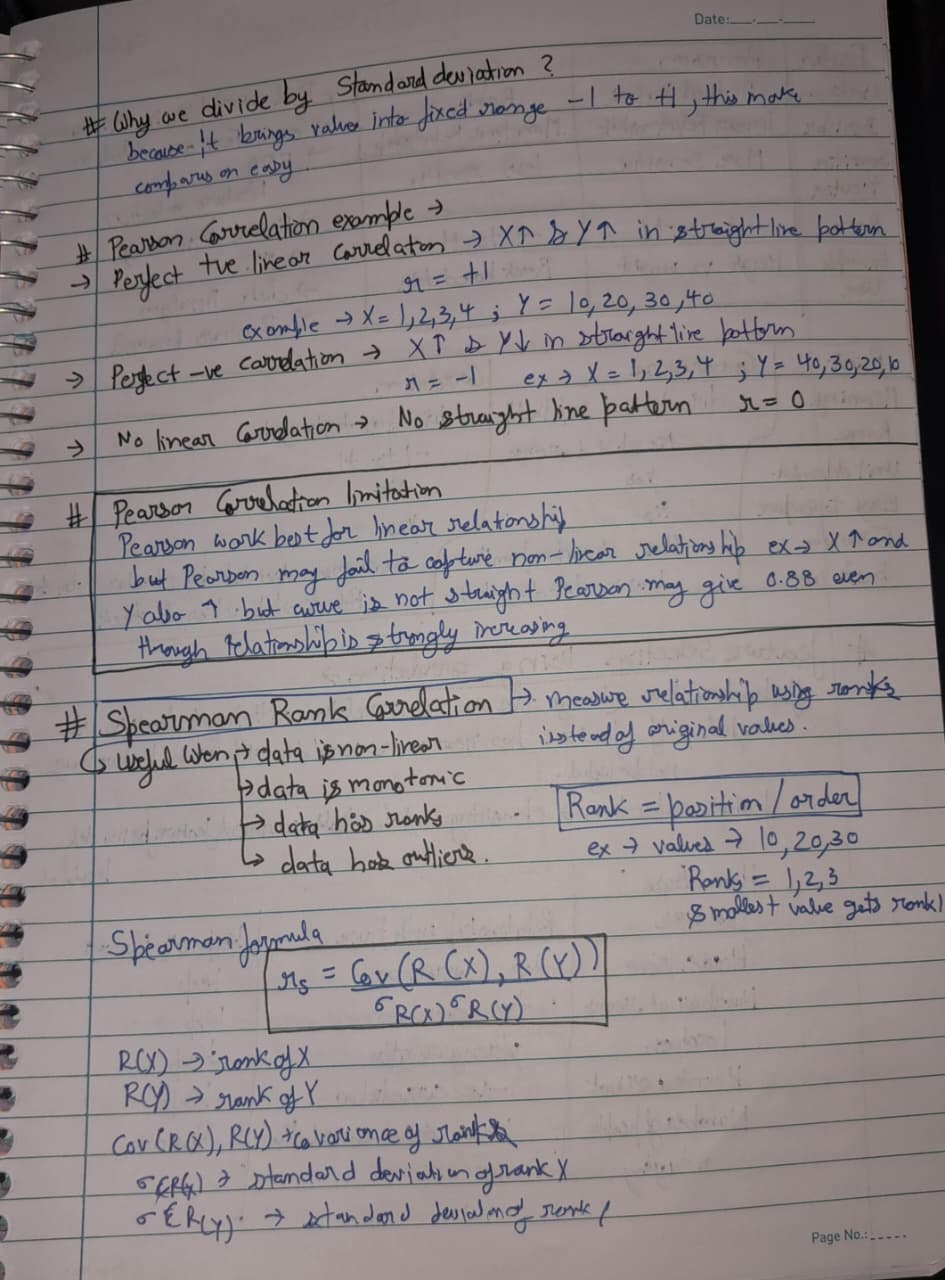

## Handwritten page 5

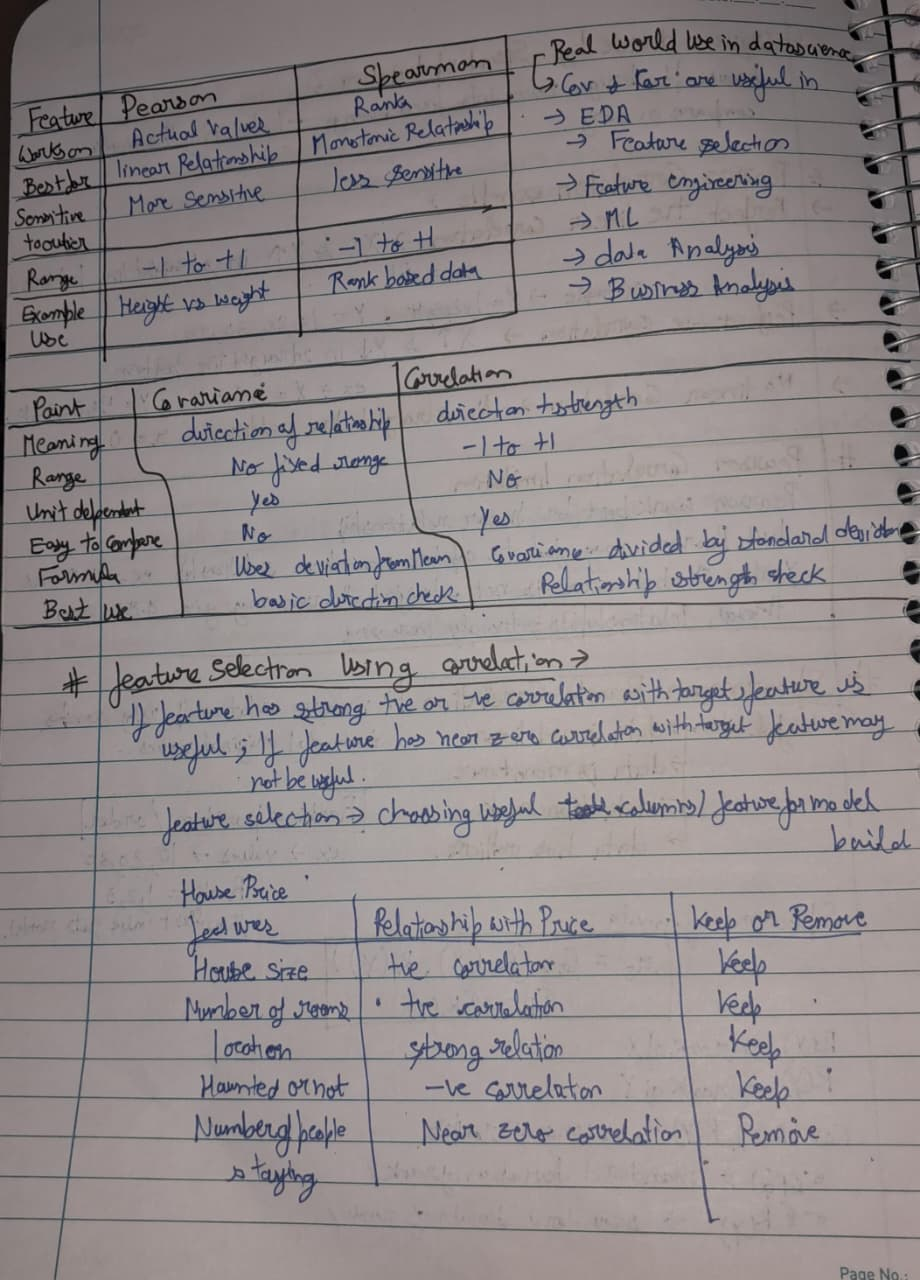